Data loaded successfully. Here are the first 5 rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  Ac

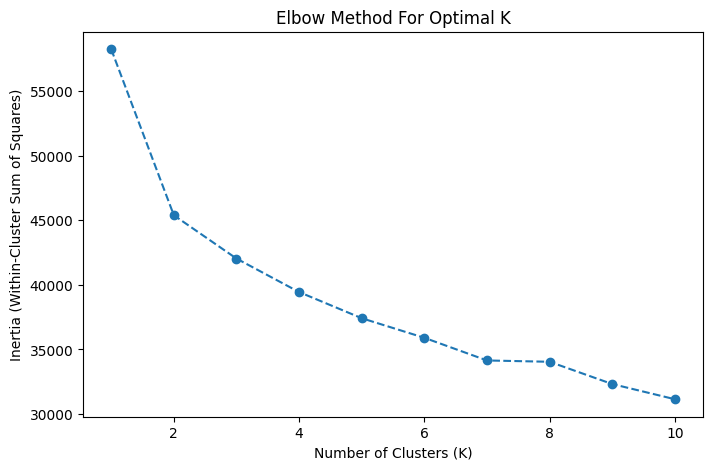


Successfully created 4 customer segments.


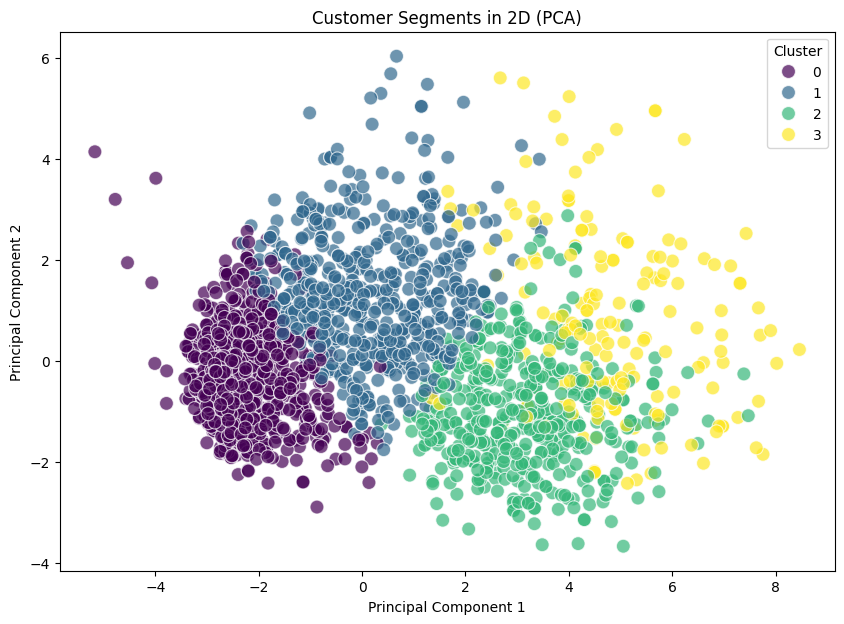


--- Customer Segment Profiles ---
           Age    Income  Total_Spent  Total_Children  Recency
Cluster                                                       
0        42.64  35322.99        95.04            1.22    49.56
1        49.12  56155.26       690.48            1.21    47.67
2        46.28  74030.24      1252.39            0.32    49.69
3        44.63  81410.67      1626.98            0.18    49.56

Segmented dataset saved to 'segmented_customers.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Data
# Ensure the file path matches where your CSV is saved
file_path = 'customer_segmentation.csv'
df = pd.read_csv(file_path)

print("Data loaded successfully. Here are the first 5 rows:")
print(df.head())

# 2. Data Cleaning and Feature Engineering
# Handle missing values (assuming 'Income' might have NaNs based on standard datasets)
df['Income'] = df['Income'].fillna(df['Income'].median())

# Calculate Customer Age (assuming the data was collected around 2014 based on Dt_Customer)
df['Age'] = 2014 - df['Year_Birth']

# Calculate total number of children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Calculate total amount spent across all product categories
# Assuming these are the exact column names from your snippet
spending_cols = [col for col in df.columns if 'Mnt' in col]
if not spending_cols:
    # Fallback to standard column names if 'Mnt' prefix varies
    spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts']
df['Total_Spent'] = df[spending_cols].sum(axis=1)

# Convert Dt_Customer to datetime and calculate tenure in days
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y', errors='coerce')
max_date = df['Dt_Customer'].max()
df['Customer_Tenure_Days'] = (max_date - df['Dt_Customer']).dt.days

# Drop columns that are no longer needed or irrelevant for clustering
columns_to_drop = ['ID', 'Year_Birth', 'Dt_Customer', 'Kidhome', 'Teenhome']
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# 3. Encoding Categorical Variables
# Identify categorical columns (like Education, Marital_Status)
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

# Use Label Encoding for categorical features
le = LabelEncoder()
for col in cat_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))

# 4. Feature Scaling
# Clustering algorithms are distance-based, so scaling is crucial
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cleaned)
df_scaled = pd.DataFrame(scaled_features, columns=df_cleaned.columns)

# 5. Determine the Optimal Number of Clusters (Elbow Method)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.show()

# 6. Apply K-Means Clustering
# Assuming the elbow indicates 4 clusters is optimal (adjust as needed based on the plot)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)

print(f"\nSuccessfully created {optimal_k} customer segments.")

# 7. Dimensionality Reduction for Visualization (PCA)
# We use PCA to reduce the data to 2 dimensions so we can plot the clusters
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)
df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

# Plot the Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments in 2D (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

# 8. Profiling the Clusters
# Display average values of key features for each cluster to understand the segments
profile_cols = ['Age', 'Income', 'Total_Spent', 'Total_Children', 'Recency']
cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)

print("\n--- Customer Segment Profiles ---")
print(cluster_profile)

# Save the final dataset with cluster assignments
output_file = 'segmented_customers.csv'
df.to_csv(output_file, index=False)
print(f"\nSegmented dataset saved to '{output_file}'")